# 06 — Análise dos resultados

Objetivo: carregar os resultados dos experimentos, calcular estatísticas agregadas e comparar comportamento por tamanho de instância, Cmax, tempo e diversidade.

In [1]:
import os
import sys
import json

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

caminho_raiz = os.path.abspath(os.path.join(os.getcwd(), ".."))
if caminho_raiz not in sys.path:
    sys.path.insert(0, caminho_raiz)

In [2]:
def carregar_configuracao(caminho_config):
    with open(caminho_config, "r", encoding="utf-8") as arquivo:
        return yaml.safe_load(arquivo)


def carregar_tabela_resultados(caminho_csv):
    if not os.path.isfile(caminho_csv):
        raise FileNotFoundError(
            f"Arquivo não encontrado: {caminho_csv}. "
            "Rode primeiro o notebook 05 para gerar o resumo Large."
        )

    return pd.read_csv(caminho_csv)


def carregar_historicos_resultados(caminho_json):
    if not os.path.isfile(caminho_json):
        return []

    with open(caminho_json, "r", encoding="utf-8") as arquivo:
        return json.load(arquivo)


def calcular_gap_percentual(valor, melhor_valor):
    if melhor_valor == 0:
        return 0.0
    return 100.0 * (valor - melhor_valor) / melhor_valor

In [3]:
caminho_config = os.path.join(caminho_raiz, "config.yaml")
config = carregar_configuracao(caminho_config)

diretorio_outputs = os.path.join(caminho_raiz, config["caminhos"]["outputs"])
caminho_csv_large = os.path.join(diretorio_outputs, "resumo_large.csv")
caminho_json_large = os.path.join(diretorio_outputs, "resumo_large_com_historicos.json")

tabela_resultados = carregar_tabela_resultados(caminho_csv_large)
historicos_resultados = carregar_historicos_resultados(caminho_json_large)

tabela_resultados.head()

,instancia,numero_jobs,numero_maquinas,indice_execucao,semente,cmax_best,geracoes,tempo_segundos,alpha_medio,beta_medio,diversidade_media
0,Ta001_2,20,5,0,42,3021.0,100,59.526,0.517865,0.4995,0.487921
1,Ta001_2,20,5,1,43,2927.0,100,103.574,0.507649,0.4995,0.494774
2,Ta001_2,20,5,2,44,2876.0,100,68.078,0.529350,0.4995,0.494872
3,Ta001_3,20,5,0,1042,2668.0,100,111.535,0.522450,0.4995,0.491520
4,Ta001_3,20,5,1,1043,3091.0,100,60.191,0.515688,0.4995,0.491666


In [4]:
tabela_estatisticas = (
    tabela_resultados
    .groupby(["instancia", "numero_jobs", "numero_maquinas"], as_index=False)
    .agg(
        execucoes=("cmax_best", "count"),
        cmax_medio=("cmax_best", "mean"),
        cmax_desvio_padrao=("cmax_best", "std"),
        cmax_melhor=("cmax_best", "min"),
        cmax_pior=("cmax_best", "max"),
        tempo_medio_segundos=("tempo_segundos", "mean"),
        alpha_medio=("alpha_medio", "mean"),
        beta_medio=("beta_medio", "mean"),
        diversidade_media=("diversidade_media", "mean"),
    )
)

tabela_estatisticas["gap_pior_melhor_percentual"] = tabela_estatisticas.apply(
    lambda linha: calcular_gap_percentual(linha["cmax_pior"], linha["cmax_melhor"]),
    axis=1,
)

tabela_estatisticas = tabela_estatisticas.sort_values(
    ["numero_jobs", "numero_maquinas", "cmax_medio"]
)

tabela_estatisticas

,instancia,numero_jobs,numero_maquinas,execucoes,cmax_medio,cmax_desvio_padrao,cmax_melhor,cmax_pior,tempo_medio_segundos,alpha_medio,beta_medio,diversidade_media,gap_pior_melhor_percentual
4,Ta001_6,20,5,3,2822.666667,52.166400,2778.0,2880.0,94.784000,0.519248,0.4995,0.491665,3.671706
5,Ta001_7,20,5,3,2841.666667,64.500646,2777.0,2906.0,79.005000,0.517624,0.4995,0.484478,4.645301
1,Ta001_3,20,5,3,2842.666667,220.912502,2668.0,3091.0,67.794333,0.524329,0.4995,0.490641,15.854573
2,Ta001_4,20,5,3,2856.666667,58.140634,2801.0,2917.0,77.887333,0.517891,0.4995,0.490541,4.141378
3,Ta001_5,20,5,3,2870.333333,82.621628,2781.0,2944.0,83.893667,0.515060,0.4995,0.490601,5.861201
6,Ta002_2,20,5,3,2907.000000,269.170949,2684.0,3206.0,77.458667,0.515606,0.4995,0.486822,19.448584
0,Ta001_2,20,5,3,2941.333333,73.554968,2876.0,3021.0,77.059333,0.518288,0.4995,0.492522,5.041725
9,Ta002_5,20,5,3,2982.333333,195.359498,2825.0,3201.0,67.153000,0.518130,0.4995,0.487350,13.309735
7,Ta002_3,20,5,3,2995.333333,104.356760,2914.0,3113.0,73.141667,0.515919,0.4995,0.494988,6.829101
8,Ta002_4,20,5,3,3029.000000,180.435584,2828.0,3177.0,81.085667,0.513235,0.4995,0.482353,12.340877


In [5]:
melhores_por_instancia = (
    tabela_resultados
    .sort_values(["instancia", "cmax_best", "tempo_segundos"])
    .groupby("instancia", as_index=False)
    .first()
)

melhores_por_instancia[
    [
        "instancia",
        "numero_jobs",
        "numero_maquinas",
        "indice_execucao",
        "semente",
        "cmax_best",
        "tempo_segundos",
        "alpha_medio",
        "beta_medio",
        "diversidade_media",
    ]
]

,instancia,numero_jobs,numero_maquinas,indice_execucao,semente,cmax_best,tempo_segundos,alpha_medio,beta_medio,diversidade_media
0,Ta001_2,20,5,2,44,2876.0,68.078,0.529350,0.4995,0.494872
1,Ta001_3,20,5,0,1042,2668.0,111.535,0.522450,0.4995,0.491520
2,Ta001_4,20,5,0,2042,2801.0,58.618,0.511548,0.4995,0.490830
3,Ta001_5,20,5,1,3043,2781.0,66.964,0.520204,0.4995,0.489567
4,Ta001_6,20,5,1,4043,2778.0,98.329,0.515284,0.4995,0.492673
5,Ta001_7,20,5,0,5042,2777.0,77.248,0.516991,0.4995,0.494605
6,Ta002_2,20,5,1,6043,2684.0,77.039,0.520273,0.4995,0.489421
7,Ta002_3,20,5,0,7042,2914.0,79.988,0.511013,0.4995,0.490669
8,Ta002_4,20,5,0,8042,2828.0,86.649,0.515801,0.4995,0.467568
9,Ta002_5,20,5,1,9043,2825.0,55.518,0.527807,0.4995,0.476975


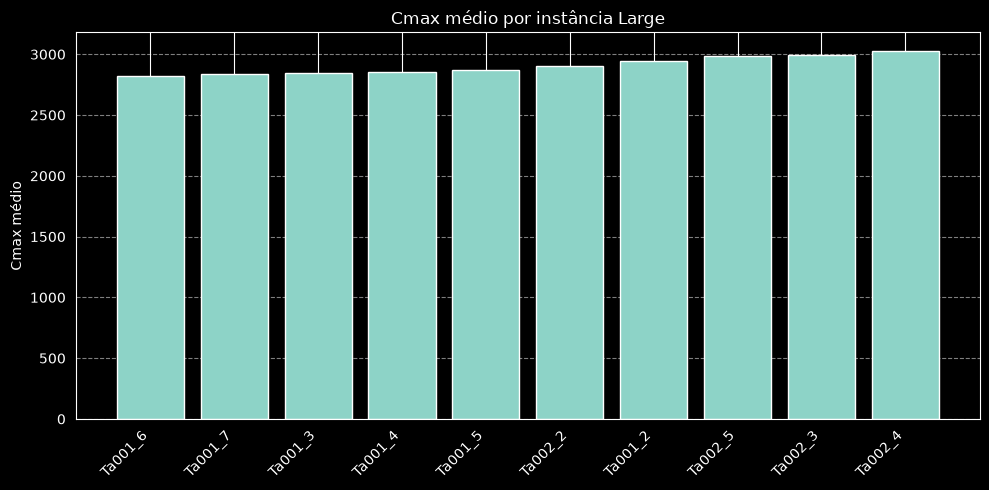

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(tabela_estatisticas["instancia"], tabela_estatisticas["cmax_medio"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cmax médio")
plt.title("Cmax médio por instância Large")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

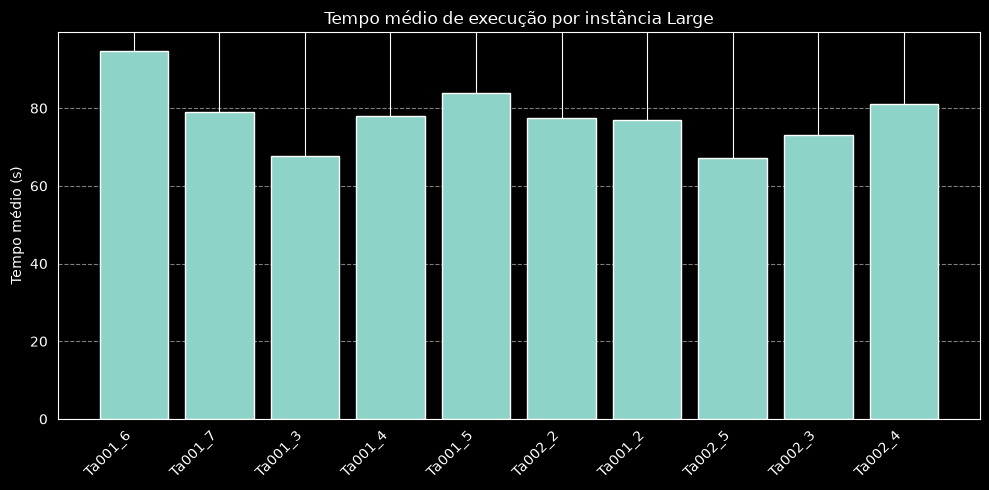

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(tabela_estatisticas["instancia"], tabela_estatisticas["tempo_medio_segundos"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Tempo médio (s)")
plt.title("Tempo médio de execução por instância Large")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

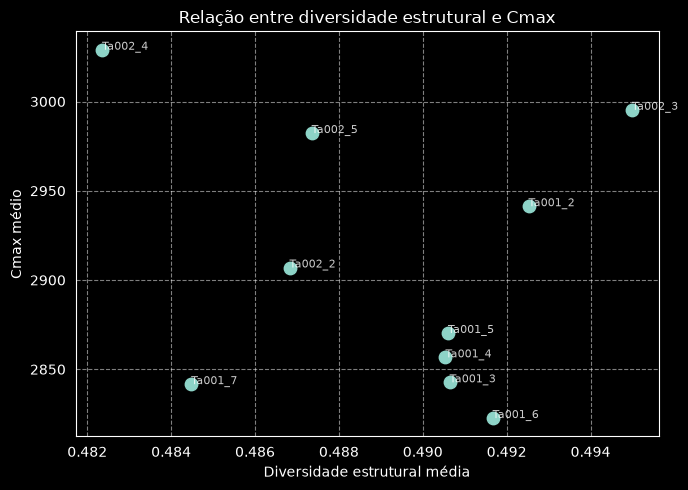

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(
    tabela_estatisticas["diversidade_media"],
    tabela_estatisticas["cmax_medio"],
    s=80,
)

for _, linha in tabela_estatisticas.iterrows():
    plt.annotate(
        linha["instancia"],
        (linha["diversidade_media"], linha["cmax_medio"]),
        fontsize=8,
        alpha=0.8,
    )

plt.xlabel("Diversidade estrutural média")
plt.ylabel("Cmax médio")
plt.title("Relação entre diversidade estrutural e Cmax")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

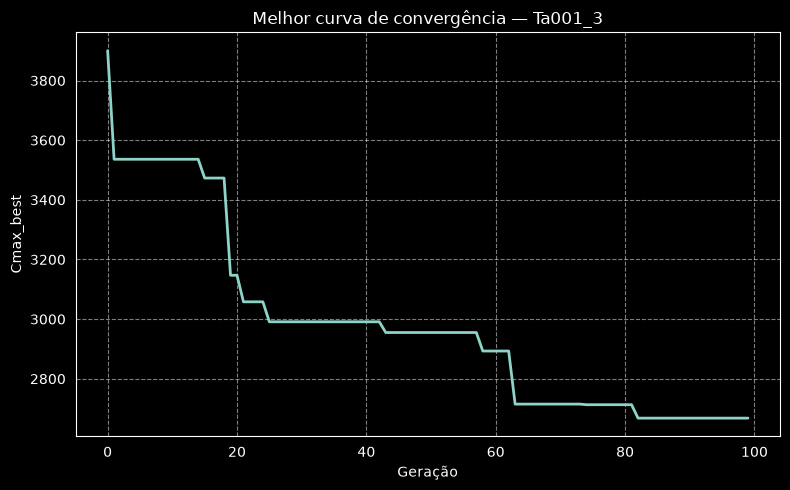

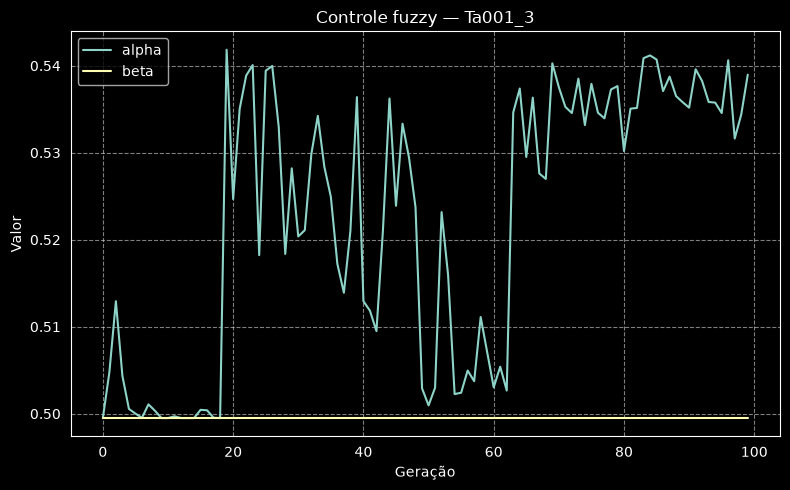

In [9]:
if historicos_resultados:
    melhor_historico = min(historicos_resultados, key=lambda linha: linha["cmax_best"])

    plt.figure(figsize=(8, 5))
    plt.plot(melhor_historico["historico_cmax_best"], linewidth=2)
    plt.xlabel("Geração")
    plt.ylabel("Cmax_best")
    plt.title(f"Melhor curva de convergência — {melhor_historico['instancia']}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(melhor_historico["historico_alpha"], label="alpha")
    plt.plot(melhor_historico["historico_beta"], label="beta")
    plt.xlabel("Geração")
    plt.ylabel("Valor")
    plt.title(f"Controle fuzzy — {melhor_historico['instancia']}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Históricos não encontrados. A análise agregada continua disponível pela tabela CSV.")

In [10]:
ranking_instancias = tabela_estatisticas.copy()
ranking_instancias["posicao_cmax"] = ranking_instancias["cmax_medio"].rank(method="dense")
ranking_instancias["posicao_tempo"] = ranking_instancias["tempo_medio_segundos"].rank(method="dense")
ranking_instancias["indice_composto"] = ranking_instancias["posicao_cmax"] + ranking_instancias["posicao_tempo"]

ranking_instancias = ranking_instancias.sort_values("indice_composto")

ranking_instancias[
    [
        "instancia",
        "cmax_medio",
        "cmax_melhor",
        "tempo_medio_segundos",
        "diversidade_media",
        "posicao_cmax",
        "posicao_tempo",
        "indice_composto",
    ]
]

,instancia,cmax_medio,cmax_melhor,tempo_medio_segundos,diversidade_media,posicao_cmax,posicao_tempo,indice_composto
1,Ta001_3,2842.666667,2668.0,67.794333,0.490641,3.0,2.0,5.0
5,Ta001_7,2841.666667,2777.0,79.005000,0.484478,2.0,7.0,9.0
9,Ta002_5,2982.333333,2825.0,67.153000,0.487350,8.0,1.0,9.0
2,Ta001_4,2856.666667,2801.0,77.887333,0.490541,4.0,6.0,10.0
4,Ta001_6,2822.666667,2778.0,94.784000,0.491665,1.0,10.0,11.0
6,Ta002_2,2907.000000,2684.0,77.458667,0.486822,6.0,5.0,11.0
0,Ta001_2,2941.333333,2876.0,77.059333,0.492522,7.0,4.0,11.0
7,Ta002_3,2995.333333,2914.0,73.141667,0.494988,9.0,3.0,12.0
3,Ta001_5,2870.333333,2781.0,83.893667,0.490601,5.0,9.0,14.0
8,Ta002_4,3029.000000,2828.0,81.085667,0.482353,10.0,8.0,18.0


## Conclusão

A análise compara as instâncias Large por qualidade da solução, estabilidade entre execuções, tempo médio e sinais internos do PBIL-Fuzzy.
Para o relatório final, use principalmente `cmax_melhor`, `cmax_medio`, `cmax_desvio_padrao`, `tempo_medio_segundos` e as curvas de convergência da melhor execução.